# Otros métodos de sintonización de hiperparámetros

El método de sintonización de hipérparámetros que implementa `GridSearchCV` es la búsqueda exhaustiva en cuadrícula, esto es, probar uno por uno todos los valores que se le entregan de los hiperparámetros. Así, sí tuviéramos que sintonizar 3 hiperparámetros, y del primero quisiéramos probar 10 valores, del segundo 50, y del tercero 3, `GridSearchCV` probaría $10*50*3 = 1500$ combinaciones posibles de hiperparámetros, cada uno por validación cruzada con el número de folds que se configure. Por ejemplo, si se usarán 5 folds, el modelo a sintonizar se entrenaría 5 veces por cada combinación de hiperparámetros, así que, en este caso, el modelo se entrenaría $1500*5 = 7500$ veces.

In [1]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=[
        'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
        'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
        'hours-per-week', 'native-country', 'income'
        ],
    na_values=' ?'
    )

df = df.dropna()
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education-num   30139 non-null  int64 
 5   marital-status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital-gain    30139 non-null  int64 
 11  capital-loss    30139 non-null  int64 
 12  hours-per-week  30139 non-null  int64 
 13  native-country  30139 non-null  object
 14  income          30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=72, 
    train_size=0.8,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (24111, 14)
Tamaño del conjunto de prueba es: (6028, 14)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.tree import DecisionTreeClassifier

cat_vars = X_train.select_dtypes(include='object').columns

te = TargetEncoder()

preproc = ColumnTransformer([
    ('te', te, cat_vars),
], remainder='passthrough')  # 'drop' to remove any other columns

pipe = Pipeline(
    [
        ('preproc', preproc),
        ('model', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=72
            )
        )
     ]
    )

In [ ]:
import time

import numpy as np
from sklearn.model_selection import GridSearchCV

start_time = time.time()

params = {
        'model__ccp_alpha': np.logspace(-4, 2, 50),
        }

grid = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    scoring='f1'
    )

grid.fit(X_train, y_train)

print(
    'Mejor F1 de validación {:.3f} con parámetros {}'.format(
        grid.best_score_,
        grid.best_params_
    )
)

end_time = time.time()
elapsed_time = end_time - start_time
print('Elapsed time is {:.3f} seconds'.format(elapsed_time))

Mejor F1 de validación 0.689 con parámetros {'model__ccp_alpha': np.float64(0.0007196856730011522)}
Elapsed time is 56.055 seconds


In [9]:
from sklearn.metrics import classification_report

y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      4527
        >50K       0.59      0.82      0.69      1501

    accuracy                           0.81      6028
   macro avg       0.76      0.82      0.78      6028
weighted avg       0.85      0.81      0.82      6028



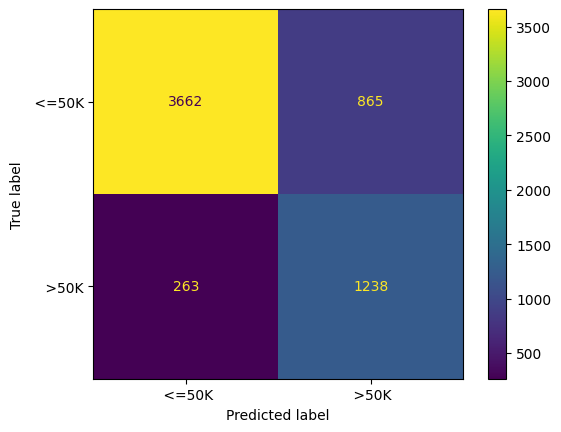

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid.best_estimator_, 
    X_test, 
    y_test, 
    display_labels=le.classes_
    );

Esto evidentemente puede tomar mucho tiempo, sobretodo si nuestra matriz de características es grande. Por todo lo anterior, han surgido métodos alternativos de sintonización de hiperparámetros.

## Búsqueda aleatoria

La búsqueda aleatoria, implementada en `RandomizedSearchCV`, ofrece una alternativa más eficiente. Funciona así:

- Espacio de búsqueda: En lugar de una parrilla de valores específicos, se define una **distribución estadística** para cada hiperparámetro (por ejemplo, una lista de valores, una distribución uniforme o normal).
- Muestreo aleatorio: Se elige un número fijo de combinaciones (`n_iter`) de manera aleatoria dentro de ese espacio de búsqueda.
- Evaluación y selección: Al igual que Grid Search, cada combinación se evalúa con validación cruzada y se selecciona la mejor.

Ventajas:

- Mucho más eficiente: Generalmente encuentra un buen modelo en mucho menos tiempo que Grid Search.
- Permite explorar un espacio de búsqueda más amplio y con valores continuos.
- Estudios han demostrado que algunos hiperparámetros son más importantes que otros. La búsqueda aleatoria tiene más probabilidad de "acertar" buenos valores para los hiperparámetros clave.

Desventajas:

- No garantiza encontrar el óptimo: Al ser un proceso aleatorio, es posible que se salte la mejor combinación posible. Sin embargo, en la práctica, la diferencia suele ser mínima.

In [11]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

start_time = time.time()

dist = {
    'model__ccp_alpha': loguniform(1e-4, 1e2),
   }


grid = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=dist,
    n_iter=20,
    scoring='f1'
    )

grid.fit(X_train, y_train)

print('Best CV f1 score is {:.3f} with params {}'.format(grid.best_score_, grid.best_params_))

end_time = time.time()
elapsed_time = end_time - start_time
print('Elapsed time is {:.3f} seconds'.format(elapsed_time))

Best CV f1 score is 0.690 with params {'model__ccp_alpha': np.float64(0.00037965645174749924)}
Elapsed time is 20.135 seconds


In [12]:
y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.93      0.82      0.87      4527
        >50K       0.61      0.82      0.70      1501

    accuracy                           0.82      6028
   macro avg       0.77      0.82      0.79      6028
weighted avg       0.85      0.82      0.83      6028



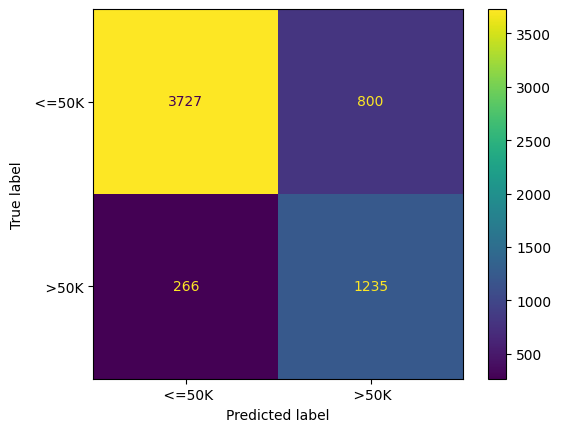

In [13]:
ConfusionMatrixDisplay.from_estimator(
    grid.best_estimator_, 
    X_test, 
    y_test, 
    display_labels=le.classes_
    );

Obsérvese como el tiempo de ejecución se reduce sensiblemente, a veces a la décima parte o más. Sin embargo, se obtienen valores similares en las métricas de los mejores modelos (ya sintonizados y entrenados), aunque no necesariamente los valores de los hiperparámetros sintonizados son los mismos.

## Optimización bayesiana

La idea de este método es simple pero poderosa: utilizar los resultados de las pruebas anteriores para decidir qué combinación probar a continuación. Este método está implementado en varias librerías como Optuna, Hyperopt, Scikit-Optimize, y Mango, siendo la primera la más popular, por lo que nos vamos a enfocar en esta.

¿Cómo funciona?

1. Modelo probabilístico sustituto (Surrogate Model): Optuna construye un modelo interno (generalmente un Proceso Gaussiano) que aproxima la función objetivo (por ejemplo, cómo el accuracy cambia según los hiperparámetros). Este modelo es poco costoso de evaluar.
2. Función de adquisición (Acquisition Function): Esta función guía la búsqueda. Ayuda a decidir el siguiente punto a probar balanceando dos objetivos:
    - Explotación (Exploitation): Probar en zonas donde el modelo sustituto predice un alto rendimiento.
    - Exploración (Exploration): Probar en zonas con alta incertidumbre, donde podría haber un pico de rendimiento inesperado.
3. Iteración:
    - Se elige una combinación de hiperparámetros usando la función de adquisición.
    - Se entrena el modelo real con esa combinación y se mide su rendimiento.
    - Se actualiza el modelo sustituto con este nuevo resultado.
    - Se repite el proceso.

Analogía: Imagine que busca petróleo en un campo. En lugar de cavar pozos en una cuadrícula (Grid Search) o al azar (Random Search), contrata a un geólogo. El geólogo analiza los resultados de los primeros pozos para crear un mapa de probabilidad de dónde podría haber más petróleo y le recomienda dónde cavar el siguiente. Eso es la optimización bayesiana.

In [18]:
import optuna
from sklearn.model_selection import cross_val_score

start_time = time.time()

def objective(trial, pipe=pipe, X_train=X_train, y_train=y_train):
    c_ccp_alpha = trial.suggest_float('model__ccp_alpha', 1e-4, 1e2, log=True)
    #c_criterion = trial.suggest_categorical('model__criterion', ['gini', 'entropy'])
    #c_max_depth = trial.suggest_int('model__max_depth', 3, 10)

    pipe.set_params(
        model__ccp_alpha=c_ccp_alpha,
        #model__criterion=c_criterion,
        #model__max_depth=c_max_depth,
    )

    score = cross_val_score(pipe, X_train, y_train, n_jobs=-1, cv=5, scoring='f1')
    cv_score = score.mean()

    return cv_score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print('Best CV f1 score is {:.3f} with params {}'.format(study.best_value, study.best_params))

end_time = time.time()
elapsed_time = end_time - start_time
print('Elapsed time is {:.3f} seconds'.format(elapsed_time))

[I 2026-05-26 22:22:42,308] A new study created in memory with name: no-name-a86b95f7-e3c9-4ee4-b7fe-a3dd0cad703f
[I 2026-05-26 22:22:42,825] Trial 0 finished with value: 0.31904366594720235 and parameters: {'model__ccp_alpha': 2.193094334110503}. Best is trial 0 with value: 0.31904366594720235.
[I 2026-05-26 22:22:43,218] Trial 1 finished with value: 0.6896280911571221 and parameters: {'model__ccp_alpha': 0.00011073512812610059}. Best is trial 1 with value: 0.6896280911571221.
[I 2026-05-26 22:22:43,626] Trial 2 finished with value: 0.31904366594720235 and parameters: {'model__ccp_alpha': 2.5372989859370803}. Best is trial 1 with value: 0.6896280911571221.
[I 2026-05-26 22:22:44,106] Trial 3 finished with value: 0.31904366594720235 and parameters: {'model__ccp_alpha': 1.7006109236710494}. Best is trial 1 with value: 0.6896280911571221.
[I 2026-05-26 22:22:44,527] Trial 4 finished with value: 0.31904366594720235 and parameters: {'model__ccp_alpha': 0.31500456495652945}. Best is trial 1

Best CV f1 score is 0.690 with params {'model__ccp_alpha': 0.00011073512812610059}
Elapsed time is 8.626 seconds


In [19]:
pipe.set_params(**study.best_params)
pipe.fit(X_train, y_train)

,steps,"[('preproc', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('te', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.93      0.82      0.87      4527
        >50K       0.60      0.82      0.69      1501

    accuracy                           0.82      6028
   macro avg       0.77      0.82      0.78      6028
weighted avg       0.85      0.82      0.83      6028



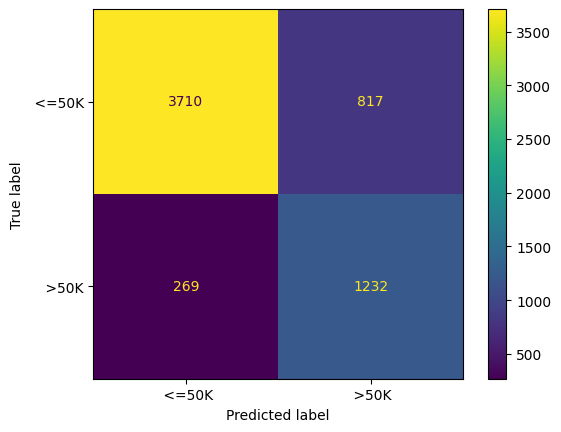

In [21]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=le.classes_);

Ventajas:

- Muy eficiente: Converge hacia una buena solución con muchas menos iteraciones que los métodos anteriores, ahorrando tiempo y recursos computacionales.
- Flexible: Permite definir espacios de búsqueda complejos y condiciones.
- Funcionalidades avanzadas: Optuna incluye mecanismos para "podar" (pruning) pruebas que no son prometedoras, deteniéndolas a mitad de camino para no gastar recursos.

Desventajas:
- Más complejo de configurar: Requiere entender conceptos como la función objetivo (objective function) y los trials.
- La selección de la función de adquisición y el modelo sustituto puede ser un problema de optimización en sí mismo (aunque Optuna lo maneja bien por defecto).